# Eval & Observability: Trajectory Evaluation

In Notebook 01, we evaluated an agent's **final output**. But in complex agentic systems, the *path* matters as much as the *destination*.

Consider a Plan-and-Execute agent tasked with researching a topic. It might:
1. Create a plan ✅
2. Execute step 1 correctly ✅
3. Execute step 2, but call the wrong tool ❌
4. Recover via replanning ✅
5. Produce a correct final answer ✅

The final answer is correct, but the **trajectory** reveals an inefficiency at step 3. Without trajectory evaluation, this failure is invisible.

**Trajectory Evaluation** assesses:
- Did the agent take the **optimal** path?
- Were there **redundant** steps (e.g., calling the same tool twice)?
- Were there **errors** that required recovery?
- How many LLM calls were needed vs. the minimum?

---

## 1. Environment Setup

In [1]:
import os
import time
from typing import Annotated, TypedDict, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
judge_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

print("Trajectory Evaluation Environment Ready!")

/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:234: FutureWarning: You are using a non-supported Python version (3.9.6). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/balamurugan/Documents/bala_github/AgenticAI-LearningPath/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with cri

Trajectory Evaluation Environment Ready!


## 2. Building a Traceable Agent
We'll build a tool-calling agent that records its full trajectory — every node visited, every tool called, every decision made.

In [2]:
# --- Tools ---
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Simulated search results
    results = {
        "python": "Python is a high-level, general-purpose programming language created by Guido van Rossum in 1991.",
        "rust": "Rust is a systems programming language focused on safety, speed, and concurrency.",
        "go": "Go (Golang) is a statically typed language designed at Google for simplicity and efficiency.",
    }
    for key, val in results.items():
        if key in query.lower():
            return val
    return f"No results found for: {query}"

@tool
def calculate(expression: str) -> str:
    """Evaluate a mathematical expression."""
    try:
        result = eval(expression)
        return f"Result: {result}"
    except Exception as e:
        return f"Error: {str(e)}"

tools = [search_web, calculate]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

print("Tools defined!")

Tools defined!


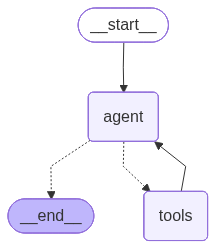

In [3]:
# --- State with Trajectory Tracking ---
class TrajectoryState(TypedDict):
    messages: Annotated[List[BaseMessage], lambda a, b: a + b]
    trajectory: List[dict]  # track each step

def agent_node(state: TrajectoryState):
    start = time.time()
    response = llm_with_tools.invoke(state["messages"])
    elapsed = round((time.time() - start) * 1000)
    
    # Record trajectory step
    step = {
        "node": "agent",
        "latency_ms": elapsed,
        "has_tool_calls": bool(response.tool_calls),
        "tool_calls": [tc["name"] for tc in response.tool_calls] if response.tool_calls else [],
    }
    trajectory = state.get("trajectory", []) + [step]
    
    print(f"  📍 AGENT ({elapsed}ms) | Tool calls: {step['tool_calls'] or 'None'}")
    return {"messages": [response], "trajectory": trajectory}

def tool_wrapper_node(state: TrajectoryState):
    """Wraps the ToolNode to add trajectory tracking."""
    start = time.time()
    
    # Get tool names from the last AI message
    last_msg = state["messages"][-1]
    tool_names = [tc["name"] for tc in last_msg.tool_calls] if last_msg.tool_calls else []
    
    # Execute tools
    result = tool_node.invoke(state)
    elapsed = round((time.time() - start) * 1000)
    
    step = {
        "node": "tools",
        "latency_ms": elapsed,
        "tools_executed": tool_names,
    }
    trajectory = state.get("trajectory", []) + [step]
    
    print(f"  🔧 TOOLS ({elapsed}ms) | Executed: {tool_names}")
    
    # Merge the tool results into the returned state
    result["trajectory"] = trajectory
    return result

def should_continue(state: TrajectoryState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

# --- Build Graph ---
builder = StateGraph(TrajectoryState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_wrapper_node)
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
builder.add_edge("tools", "agent")

app = builder.compile()

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph visualization failed.")

## 3. Running and Capturing the Trajectory

In [4]:
query = "Search the web for information about Python and then calculate 2**10."
inputs = {
    "messages": [HumanMessage(content=query)],
    "trajectory": []
}

print(f"Query: {query}")
print("=" * 60)

final_state = None
for chunk in app.stream(inputs, stream_mode="values"):
    final_state = chunk

# Extract the trajectory
trajectory = final_state.get("trajectory", [])

print("\n" + "=" * 60)
print(f"Trajectory captured: {len(trajectory)} steps")

Query: Search the web for information about Python and then calculate 2**10.
  📍 AGENT (2053ms) | Tool calls: ['search_web']
  🔧 TOOLS (1ms) | Executed: ['search_web']
  📍 AGENT (1280ms) | Tool calls: ['calculate']
  🔧 TOOLS (1ms) | Executed: ['calculate']
  📍 AGENT (1199ms) | Tool calls: None

Trajectory captured: 5 steps


## 4. Heuristic Trajectory Evaluation
Before using an LLM judge, we can apply rule-based checks to the trajectory.

In [5]:
def evaluate_trajectory_heuristic(trajectory: List[dict]) -> dict:
    """Apply heuristic rules to evaluate the trajectory."""
    total_steps = len(trajectory)
    agent_steps = [s for s in trajectory if s["node"] == "agent"]
    tool_steps = [s for s in trajectory if s["node"] == "tools"]
    
    # Check for redundant tool calls (same tool called >1 time)
    all_tool_calls = []
    for step in tool_steps:
        all_tool_calls.extend(step.get("tools_executed", []))
    
    from collections import Counter
    tool_counts = Counter(all_tool_calls)
    redundant_tools = {t: c for t, c in tool_counts.items() if c > 1}
    
    # Calculate total latency
    total_latency = sum(s.get("latency_ms", 0) for s in trajectory)
    
    # Efficiency score: fewer steps = better
    efficiency = max(0, 10 - total_steps)  # Simple scoring: 10 points minus steps
    
    result = {
        "total_steps": total_steps,
        "agent_invocations": len(agent_steps),
        "tool_invocations": len(tool_steps),
        "unique_tools_used": list(set(all_tool_calls)),
        "redundant_tools": redundant_tools,
        "total_latency_ms": total_latency,
        "efficiency_score": efficiency,
        "has_redundant_calls": len(redundant_tools) > 0,
    }
    return result

heuristic_result = evaluate_trajectory_heuristic(trajectory)

print("--- Heuristic Trajectory Evaluation ---")
for key, value in heuristic_result.items():
    print(f"  {key}: {value}")

--- Heuristic Trajectory Evaluation ---
  total_steps: 5
  agent_invocations: 3
  tool_invocations: 2
  unique_tools_used: ['search_web', 'calculate']
  redundant_tools: {}
  total_latency_ms: 4534
  efficiency_score: 5
  has_redundant_calls: False


## 5. LLM-as-a-Judge for Trajectories
For deeper analysis, we ask an LLM to assess the trajectory against an optimal reference path.

In [6]:
class TrajectoryEvalResult(BaseModel):
    """LLM judge evaluation of an agent's trajectory."""
    efficiency_score: int = Field(description="1-5: Was the trajectory optimal? 5 = minimum possible steps.")
    tool_selection_score: int = Field(description="1-5: Were the right tools selected for each step? 5 = perfect selection.")
    error_recovery_score: int = Field(description="1-5: If errors occurred, how well did the agent recover? 5 = perfect recovery. If no errors, give 5.")
    overall_score: int = Field(description="1-5: Overall trajectory quality.")
    reasoning: str = Field(description="Detailed explanation of the scores.")
    suggested_optimal_path: str = Field(description="What the optimal trajectory should have been.")

trajectory_judge = judge_llm.with_structured_output(TrajectoryEvalResult)

def evaluate_trajectory_llm(query: str, trajectory: List[dict], final_answer: str) -> TrajectoryEvalResult:
    """Use an LLM to judge the agent's trajectory."""
    # Format trajectory for the judge
    traj_str = ""
    for i, step in enumerate(trajectory):
        traj_str += f"\nStep {i+1}: Node='{step['node']}' | Latency={step.get('latency_ms', '?')}ms"
        if step["node"] == "agent":
            traj_str += f" | Tool calls: {step.get('tool_calls', 'None')}"
        elif step["node"] == "tools":
            traj_str += f" | Executed: {step.get('tools_executed', [])}"
    
    system_msg = """You are an expert evaluator of AI agent trajectories.
    Given a user query, the agent's step-by-step trajectory, and the final answer,
    evaluate how efficiently and correctly the agent reached the answer.
    
    Consider:
    - Were unnecessary steps taken?
    - Were the correct tools selected?
    - Could the agent have reached the answer in fewer steps?
    - Were there any errors or recovery loops?"""
    
    prompt = f"""USER QUERY: {query}

AGENT TRAJECTORY:
{traj_str}

FINAL ANSWER: {final_answer}

Evaluate this trajectory."""
    
    return trajectory_judge.invoke([HumanMessage(content=f"{system_msg}\n\n{prompt}")])

# Get the final answer from the last AI message
final_answer = ""
for msg in reversed(final_state["messages"]):
    if isinstance(msg, AIMessage) and msg.content and not msg.tool_calls:
        final_answer = msg.content
        break

traj_eval = evaluate_trajectory_llm(query, trajectory, final_answer)

print("--- LLM Trajectory Evaluation ---")
print(f"  Efficiency:       {traj_eval.efficiency_score}/5")
print(f"  Tool Selection:   {traj_eval.tool_selection_score}/5")
print(f"  Error Recovery:   {traj_eval.error_recovery_score}/5")
print(f"  Overall:          {traj_eval.overall_score}/5")
print(f"\n  Reasoning: {traj_eval.reasoning}")
print(f"\n  Optimal Path: {traj_eval.suggested_optimal_path}")

--- LLM Trajectory Evaluation ---
  Efficiency:       5/5
  Tool Selection:   5/5
  Error Recovery:   5/5
  Overall:          5/5

  Reasoning: The agent efficiently addressed both components of the user query: searching for Python information and calculating 2**10. It correctly selected the `search_web` tool for the information retrieval task and the `calculate` tool for the mathematical operation. No unnecessary steps were taken, and the trajectory shows no signs of errors or recovery attempts. The final answer accurately provides both pieces of requested information.

  Optimal Path: 1. Call `search_web` for 'Python'.
2. Call `calculate` for '2**10'.
3. Combine results to form the final answer. This is the optimal sequential path, which the agent followed.


## 6. Comparing Trajectories Across Runs
In production, you would run the same query multiple times and compare trajectories to detect non-determinism and identify the most efficient path.

In [7]:
# Run the agent 3 times on the same query and compare
comparison_results = []

for run_num in range(3):
    print(f"\n--- Run {run_num + 1} ---")
    inputs = {"messages": [HumanMessage(content=query)], "trajectory": []}
    
    final = None
    for chunk in app.stream(inputs, stream_mode="values"):
        final = chunk
    
    traj = final.get("trajectory", [])
    heuristic = evaluate_trajectory_heuristic(traj)
    comparison_results.append({
        "run": run_num + 1,
        "total_steps": heuristic["total_steps"],
        "total_latency_ms": heuristic["total_latency_ms"],
        "efficiency_score": heuristic["efficiency_score"],
        "has_redundant_calls": heuristic["has_redundant_calls"],
    })

print("\n" + "=" * 60)
print("TRAJECTORY COMPARISON")
print(f"{'Run':<6} {'Steps':<8} {'Latency (ms)':<15} {'Efficiency':<12} {'Redundant?'}")
print("-" * 55)
for r in comparison_results:
    print(f"{r['run']:<6} {r['total_steps']:<8} {r['total_latency_ms']:<15} {r['efficiency_score']:<12} {r['has_redundant_calls']}")


--- Run 1 ---
  📍 AGENT (1631ms) | Tool calls: ['search_web', 'calculate']
  🔧 TOOLS (1ms) | Executed: ['search_web', 'calculate']
  📍 AGENT (1294ms) | Tool calls: None

--- Run 2 ---
  📍 AGENT (1777ms) | Tool calls: ['search_web', 'calculate']
  🔧 TOOLS (1ms) | Executed: ['search_web', 'calculate']
  📍 AGENT (1332ms) | Tool calls: None

--- Run 3 ---
  📍 AGENT (1740ms) | Tool calls: ['search_web', 'calculate']
  🔧 TOOLS (1ms) | Executed: ['search_web', 'calculate']
  📍 AGENT (1432ms) | Tool calls: None

TRAJECTORY COMPARISON
Run    Steps    Latency (ms)    Efficiency   Redundant?
-------------------------------------------------------
1      3        2926            7            False
2      3        3110            7            False
3      3        3173            7            False


## Summary

Trajectory evaluation reveals the **quality of reasoning**, not just the quality of the answer.

| Metric | What It Measures | Why It Matters |
| :--- | :--- | :--- |
| **Step Count** | Total nodes visited | Cost optimization — fewer LLM calls = lower API spend |
| **Tool Selection** | Were the right tools chosen? | Correctness — wrong tools waste tokens and introduce errors |
| **Redundancy** | Repeated tool calls | Efficiency — indicates confused reasoning |
| **Error Recovery** | How the agent handled failures | Resilience — critical for production reliability |
| **Latency Profile** | Time per step | Performance — identifies bottleneck nodes |

> **Pro-Tip**: Define an `expected_trajectory` alongside each test case in your evaluation dataset. This lets you automatically flag runs where the agent took a different (potentially suboptimal) path, even if the final answer is correct.

In the next notebook, we'll bring all of these techniques together to build an **Automated Benchmarking** pipeline.